# End-to-End Predictive Modeling on the Titanic Dataset

## 1. Data Import and Initial Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
import seaborn as sns
sns.set_theme(style="whitegrid", color_codes=True)
import warnings
warnings.simplefilter(action='ignore')

## 2. Loading and Previewing the Dataset

In [2]:
# Load training and test datasets
train_df = pd.read_csv("titanic/train.csv")
test_df = pd.read_csv("titanic/test.csv")

# Preview the training data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(f'Training set contains {train_df.shape[0]} samples.')

Training set contains 891 samples.


In [4]:
# Preview the test data
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
print(f'Test set contains {test_df.shape[0]} samples.')

Test set contains 418 samples.


**Key Note:** The test dataset lacks the target variable (`Survived`). Our objective is to build a predictive model on the training data and apply it to the test set.

## 3. Data Quality Assessment and Cleaning

### 3.1. Identifying Missing Values

In [6]:
# Check for missing values in the training data
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 3.2. Handling Missing 'Age' Values
20% of Age records are missing. The distribution is right-skewed, so median imputation is more appropriate than mean imputation.

In [7]:
print(f'Percent of missing "Age" records: {train_df["Age"].isnull().sum()/train_df.shape[0]*100:.2f}%')

Percent of missing "Age" records: 19.87%


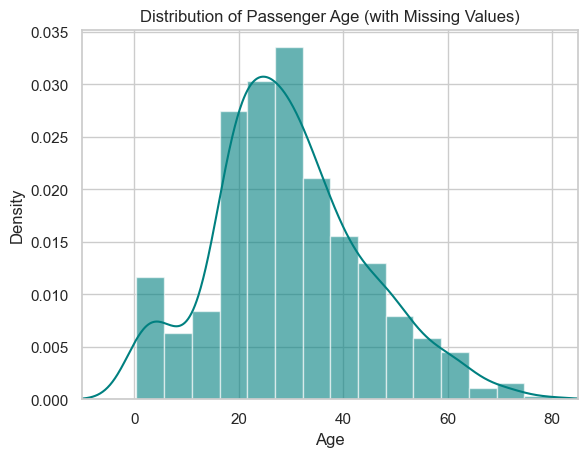

In [8]:
# Visualize Age distribution
ax = train_df["Age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
train_df["Age"].plot(kind='density', color='teal')
ax.set(xlabel='Age', title='Distribution of Passenger Age (with Missing Values)')
plt.xlim(-10,85)
plt.show()

In [9]:
print(f'Mean Age: {train_df["Age"].mean(skipna=True):.2f}')
print(f'Median Age: {train_df["Age"].median(skipna=True):.2f}')

Mean Age: 29.70
Median Age: 28.00


**Decision:** Impute missing Age values with the **median (28.0)** to avoid bias from outliers.

### 3.3. Handling Missing 'Cabin' Values

In [10]:
print(f'Percent of missing "Cabin" records: {train_df["Cabin"].isnull().sum()/train_df.shape[0]*100:.2f}%')

Percent of missing "Cabin" records: 77.10%


**Decision:** Exclude the 'Cabin' variable due to excessive missing data (>77%).

### 3.4. Handling Missing 'Embarked' Values

In [11]:
print(f'Percent of missing "Embarked" records: {train_df["Embarked"].isnull().sum()/train_df.shape[0]*100:.2f}%')

Percent of missing "Embarked" records: 0.22%


Impute with the most frequent boarding port.

Passenger count by embarkation port:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


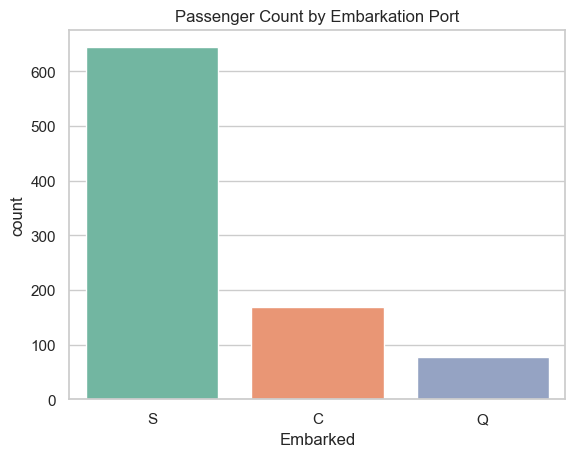

In [12]:
print('Passenger count by embarkation port:')
print(train_df['Embarked'].value_counts())
sns.countplot(x='Embarked', data=train_df, palette='Set2')
plt.title('Passenger Count by Embarkation Port')
plt.show()

In [13]:
print(f"Most common embarkation port: {train_df['Embarked'].value_counts().idxmax()}")

Most common embarkation port: S


**Decision:** Impute 2 missing 'Embarked' values with **'S'** (Southampton).

### 3.5. Creating the Cleaned Training Dataset

In [14]:
# Create a clean copy
train_data = train_df.copy()

# Apply imputation strategies
train_data["Age"].fillna(train_df["Age"].median(skipna=True), inplace=True)
train_data["Embarked"].fillna(train_df['Embarked'].value_counts().idxmax(), inplace=True)
train_data.drop('Cabin', axis=1, inplace=True)

# Verify cleaning
print("Missing values after cleaning:")
print(train_data.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


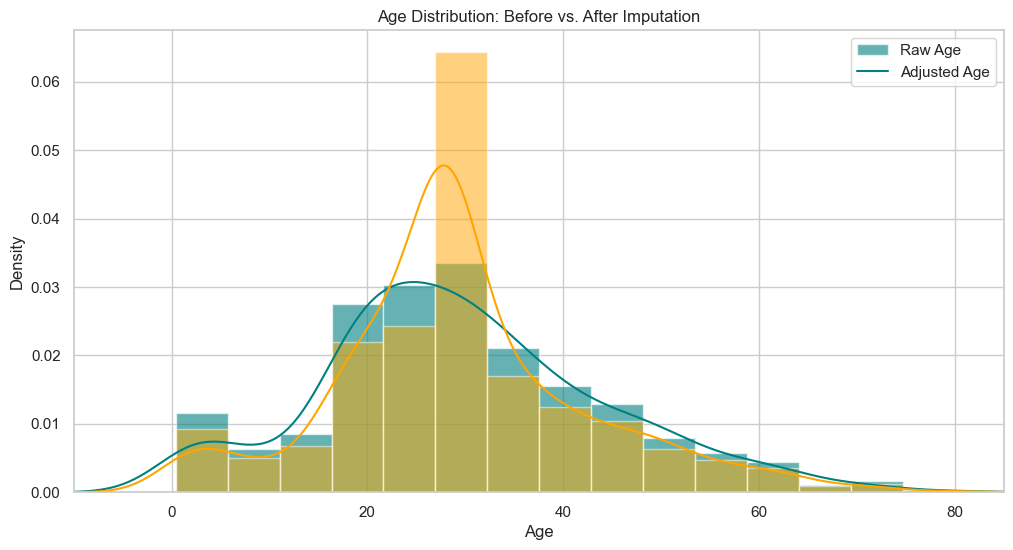

In [15]:
# Compare Age distributions before and after imputation
plt.figure(figsize=(12,6))
ax = train_df["Age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6, label='Original')
train_df["Age"].plot(kind='density', color='teal')
ax = train_data["Age"].hist(bins=15, density=True, stacked=True, color='orange', alpha=0.5, label='Imputed')
train_data["Age"].plot(kind='density', color='orange')
ax.legend(['Raw Age', 'Adjusted Age'])
ax.set(xlabel='Age', title='Age Distribution: Before vs. After Imputation')
plt.xlim(-10,85)
plt.show()

### 3.6. Feature Engineering

In [16]:
# Create 'TravelAlone' feature from SibSp and Parch
train_data['TravelAlone'] = np.where((train_data["SibSp"] + train_data["Parch"]) > 0, 0, 1)
train_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

# Convert categorical variables to dummy/indicator variables
training = pd.get_dummies(train_data, columns=["Pclass", "Embarked", "Sex"])
training.drop('Sex_female', axis=1, inplace=True)  # Avoid dummy variable trap
training.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)  # Remove non-predictive columns

final_train = training
final_train.head()

,Survived,Age,Fare,TravelAlone,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,0,22.0,7.2500,0,False,False,True,False,False,True,True
1,1,38.0,71.2833,0,True,False,False,True,False,False,False
2,1,26.0,7.9250,1,False,False,True,False,False,True,False
3,1,35.0,53.1000,0,True,False,False,False,False,True,False
4,0,35.0,8.0500,1,False,False,True,False,False,True,True


### 3.7. Applying Consistent Transformations to Test Data

In [17]:
# Check test data missing values
print("Initial missing values in test set:")
print(test_df.isnull().sum())

Initial missing values in test set:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [18]:
# Apply identical transformations to test data
test_data = test_df.copy()
test_data["Age"].fillna(train_df["Age"].median(skipna=True), inplace=True)
test_data["Fare"].fillna(train_df["Fare"].median(skipna=True), inplace=True)  # One missing fare
test_data.drop('Cabin', axis=1, inplace=True)
test_data['TravelAlone'] = np.where((test_data["SibSp"] + test_data["Parch"]) > 0, 0, 1)
test_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

testing = pd.get_dummies(test_data, columns=["Pclass", "Embarked", "Sex"])
testing.drop('Sex_female', axis=1, inplace=True)
testing.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

final_test = testing
final_test.head()

,Age,Fare,TravelAlone,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,34.5,7.8292,1,False,False,True,False,True,False,True
1,47.0,7.0000,0,False,False,True,False,False,True,False
2,62.0,9.6875,1,False,True,False,False,True,False,True
3,27.0,8.6625,1,False,False,True,False,False,True,True
4,22.0,12.2875,0,False,False,True,False,False,True,False


## 4. Exploratory Data Analysis

### 4.1. Age and Survival Relationship

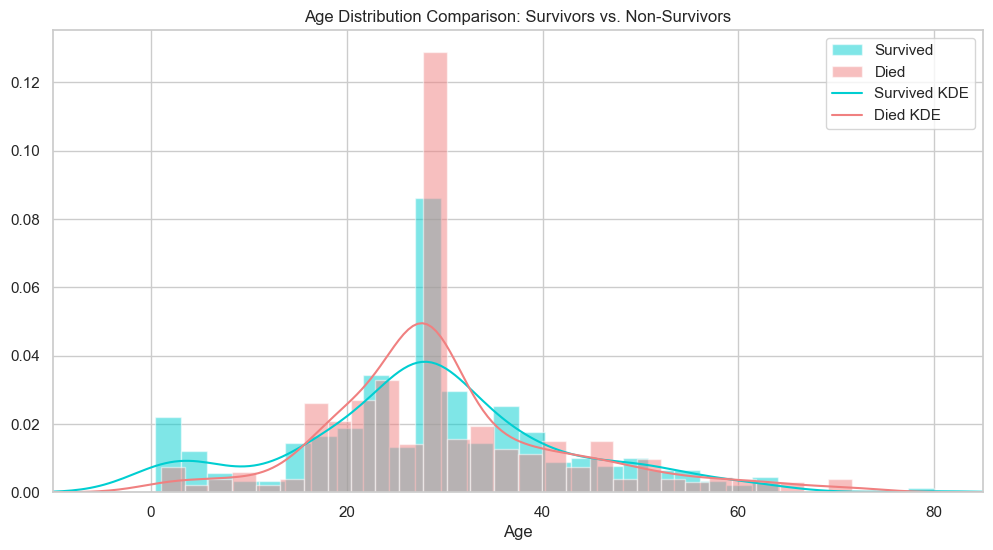

In [19]:
# Compare age distributions between survivors and non-survivors
plt.figure(figsize=(12, 6))
survived_ages = final_train["Age"][final_train.Survived == 1].dropna()
died_ages = final_train["Age"][final_train.Survived == 0].dropna()

plt.hist(survived_ages, bins=30, density=True, alpha=0.5, color="darkturquoise", label="Survived")
plt.hist(died_ages, bins=30, density=True, alpha=0.5, color="lightcoral", label="Died")

# Add kernel density estimates
from scipy import stats
for data, color, label in [(survived_ages, "darkturquoise", "Survived KDE"),
                           (died_ages, "lightcoral", "Died KDE")]:
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(-10, 85, 200)
    plt.plot(x_range, kde(x_range), color=color, label=label)

plt.title("Age Distribution Comparison: Survivors vs. Non-Survivors")
plt.xlabel("Age")
plt.xlim(-10, 85)
plt.legend()
plt.show()

**Insight:** Children (ages 0-16) appear to have higher survival rates, suggesting prioritization during evacuation.

In [20]:
# Create binary feature for minors
final_train['IsMinor'] = np.where(final_train['Age'] <= 16, 1, 0)
final_test['IsMinor'] = np.where(final_test['Age'] <= 16, 1, 0)

### 4.2. Fare and Survival Relationship

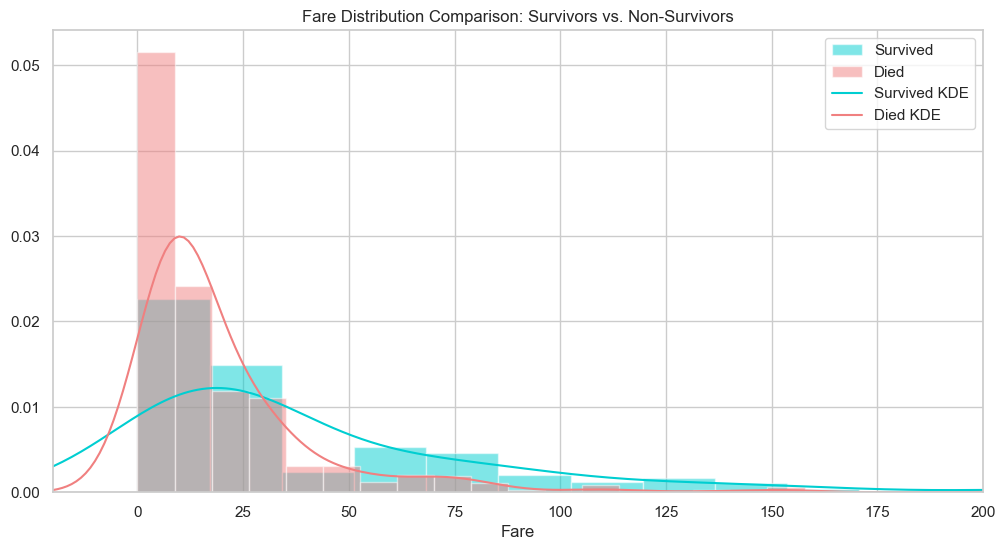

In [21]:
plt.figure(figsize=(12, 6))
survived_fares = final_train["Fare"][final_train.Survived == 1].dropna()
died_fares = final_train["Fare"][final_train.Survived == 0].dropna()

plt.hist(survived_fares, bins=30, density=True, alpha=0.5, color="darkturquoise", label="Survived")
plt.hist(died_fares, bins=30, density=True, alpha=0.5, color="lightcoral", label="Died")

# Add kernel density estimates
for data, color, label in [(survived_fares, "darkturquoise", "Survived KDE"),
                           (died_fares, "lightcoral", "Died KDE")]:
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(-20, 200, 200)
    plt.plot(x_range, kde(x_range), color=color, label=label)

plt.title("Fare Distribution Comparison: Survivors vs. Non-Survivors")
plt.xlabel("Fare")
plt.xlim(-20, 200)
plt.legend()
plt.show()

**Insight:** Higher fares correlate strongly with survival, likely serving as a proxy for passenger class and cabin location.

### 4.3. Passenger Class Impact

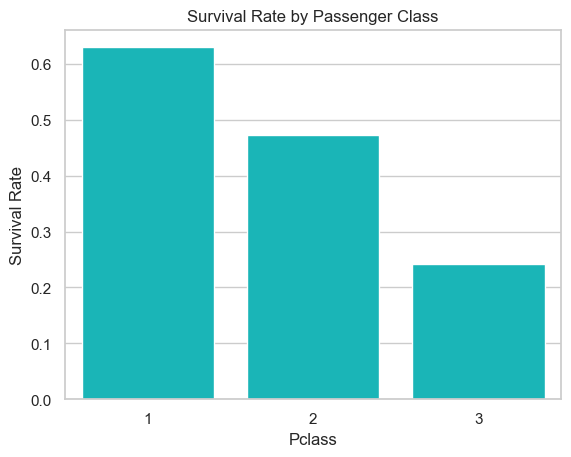

In [22]:
sns.barplot(x='Pclass', y='Survived', data=train_df, color="darkturquoise", errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Insight:** Strong socio-economic gradient: 1st class (63% survival) > 2nd class (47%) > 3rd class (24%).

### 4.4. Embarkation Port Analysis

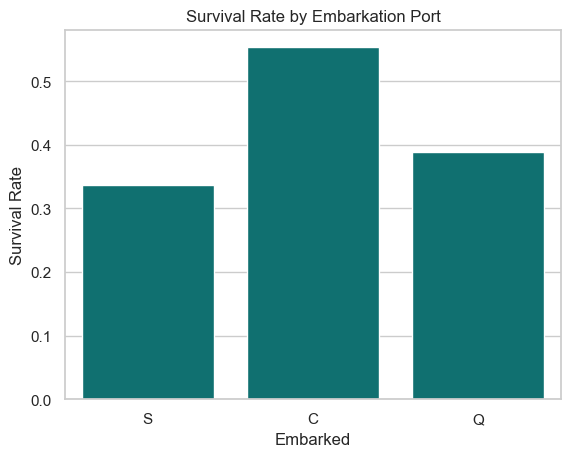

In [23]:
sns.barplot(x='Embarked', y='Survived', data=train_df, color="teal", errorbar=None)
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

**Insight:** Cherbourg passengers had highest survival rates (55%), possibly due to different passenger demographics.

### 4.5. Traveling Alone vs. With Family

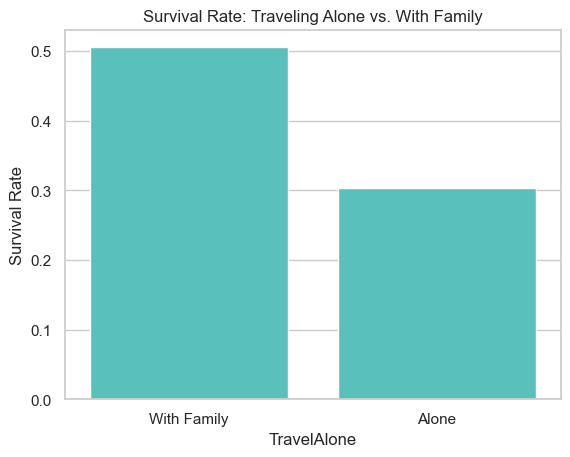

In [24]:
sns.barplot(x='TravelAlone', y='Survived', data=final_train, color="mediumturquoise", errorbar=None)
plt.title('Survival Rate: Traveling Alone vs. With Family')
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.ylabel('Survival Rate')
plt.show()

**Insight:** Passengers traveling with family had 10% higher survival rates, possibly due to coordinated evacuation efforts.

### 4.6. Gender Analysis

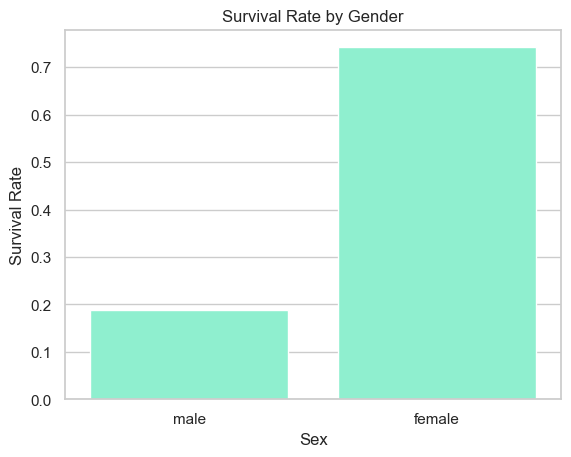

In [25]:
sns.barplot(x='Sex', y='Survived', data=train_df, color="aquamarine", errorbar=None)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

**Insight:** Most significant predictor - females had 74% survival rate vs. 19% for males, reflecting "women and children first" protocol.

## 5. Model Development with Logistic Regression

### 5.1. Feature Selection Using Recursive Feature Elimination

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, RFECV

# Define candidate features
cols = ["Age", "Fare", "TravelAlone", "Pclass_1", "Pclass_2",
        "Embarked_C", "Embarked_S", "Sex_male", "IsMinor"]
X = final_train[cols]
y = final_train["Survived"]

# Initial RFE with 8 features
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=8)
rfe = rfe.fit(X, y)
print("RFE Selected Features:", list(X.columns[rfe.support_]))

RFE Selected Features: ['Age', 'TravelAlone', 'Pclass_1', 'Pclass_2', 'Embarked_C', 'Embarked_S', 'Sex_male', 'IsMinor']


Optimal number of features: 9
Selected features: ['Age', 'Fare', 'TravelAlone', 'Pclass_1', 'Pclass_2', 'Embarked_C', 'Embarked_S', 'Sex_male', 'IsMinor']


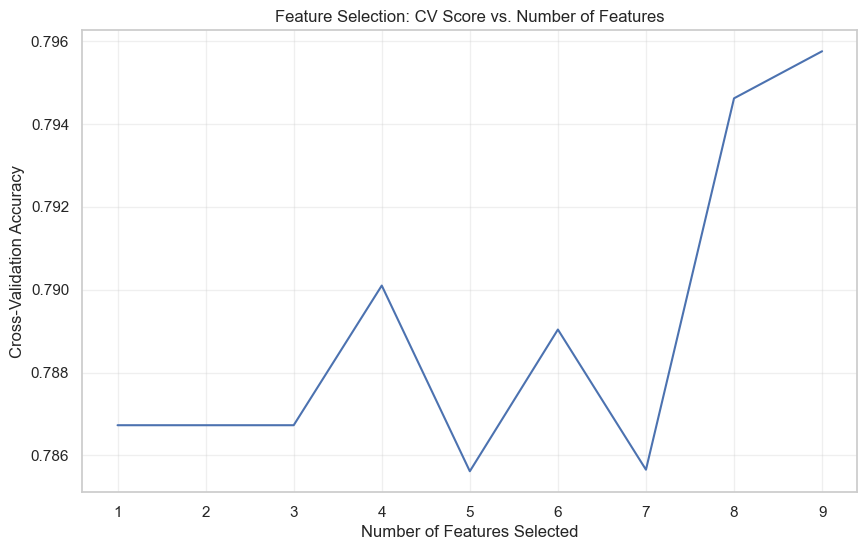

In [27]:
# Cross-validated RFE to find optimal feature count
rfecv = RFECV(estimator=LogisticRegression(max_iter=1000), step=1, cv=10, scoring="accuracy")
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {list(X.columns[rfecv.support_])}")

# Plot feature selection performance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Feature Selection: CV Score vs. Number of Features")
plt.grid(True, alpha=0.3)
plt.show()

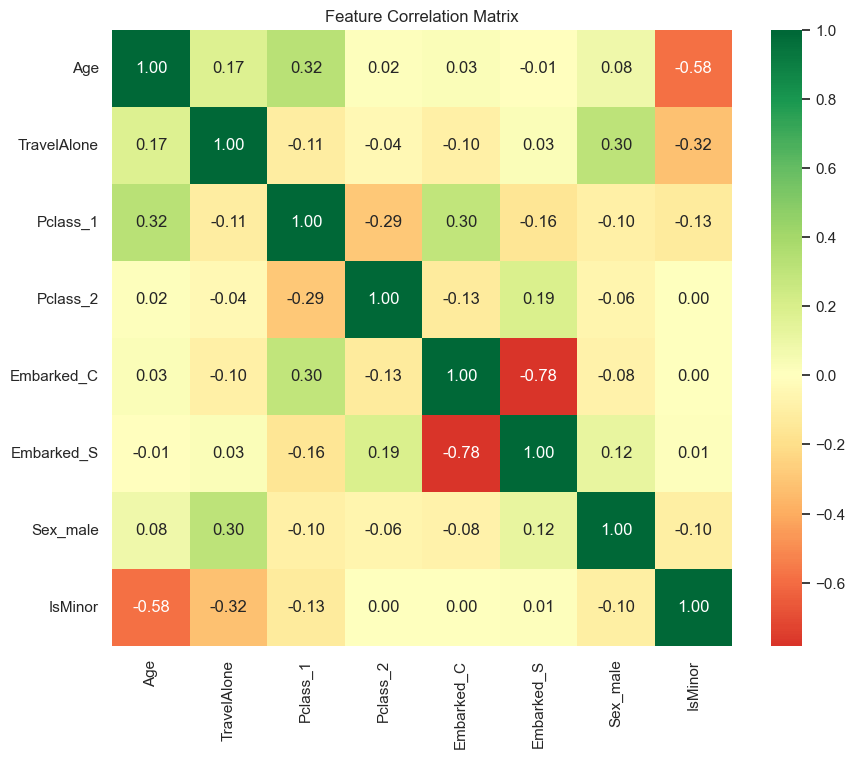

In [28]:
# Final feature set (Fare excluded by RFECV)
Selected_features = ['Age', 'TravelAlone', 'Pclass_1', 'Pclass_2',
                     'Embarked_C', 'Embarked_S', 'Sex_male', 'IsMinor']
X = final_train[Selected_features]

# Feature correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap="RdYlGn", center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### 5.2. Model Evaluation: Train/Test Split

TRAIN/TEST SPLIT RESULTS
Accuracy: 0.788
Log Loss: 0.480

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



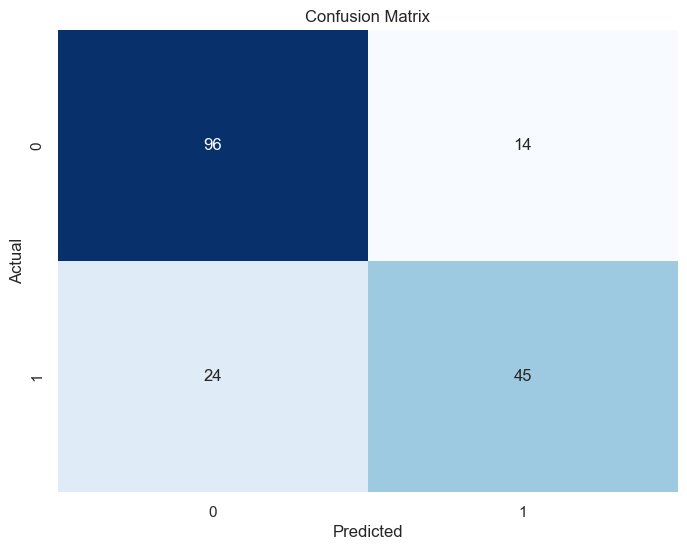

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

# Train and evaluate
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

print("=" * 50)
print("TRAIN/TEST SPLIT RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5.3. Cross-Validation for Robust Performance Estimation

In [30]:
from sklearn.model_selection import cross_validate, cross_val_score

# Define evaluation metrics
scoring = {'accuracy': 'accuracy', 
           'log_loss': 'neg_log_loss',
           'precision': 'precision',
           'recall': 'recall',
           'f1': 'f1'}

logreg = LogisticRegression(max_iter=1000)
results = cross_validate(logreg, X, y, cv=10, scoring=scoring, return_train_score=False)

print("=" * 50)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)
for metric in scoring.keys():
    mean_score = -results[f'test_{metric}'].mean() if metric == 'log_loss' else results[f'test_{metric}'].mean()
    std_score = results[f'test_{metric}'].std()
    print(f"{metric.capitalize():12s}: {mean_score:.3f} (+/- {std_score:.3f})")

10-FOLD CROSS-VALIDATION RESULTS
Accuracy    : 0.796 (+/- 0.024)
Log_loss    : 0.454 (+/- 0.037)
Precision   : 0.756 (+/- 0.039)
Recall      : 0.696 (+/- 0.073)
F1          : 0.722 (+/- 0.040)


### 5.4. Evaluating Feature Importance: The Case of 'Fare'

In [31]:
# Test model performance with and without 'Fare' feature
cols_with_fare = Selected_features + ['Fare']
X_with_fare = final_train[cols_with_fare]

# Cross-validation comparison
results_with_fare = cross_validate(logreg, X_with_fare, y, cv=10, scoring=scoring, return_train_score=False)

print("=" * 50)
print("FEATURE IMPORTANCE: WITH VS. WITHOUT 'FARE'")
print("=" * 50)
print(f"{'Metric':12s} {'Without Fare':>12s} {'With Fare':>12s} {'Difference':>12s}")
print("-" * 50)
for metric in scoring.keys():
    without = -results[f'test_{metric}'].mean() if metric == 'log_loss' else results[f'test_{metric}'].mean()
    with_fare = -results_with_fare[f'test_{metric}'].mean() if metric == 'log_loss' else results_with_fare[f'test_{metric}'].mean()
    diff = with_fare - without
    diff_str = f"{diff:+.3f}" if metric != 'log_loss' else f"{-diff:+.3f}"
    print(f"{metric.capitalize():12s} {without:12.3f} {with_fare:12.3f} {diff_str:>12s}")

FEATURE IMPORTANCE: WITH VS. WITHOUT 'FARE'
Metric       Without Fare    With Fare   Difference
--------------------------------------------------
Accuracy            0.796        0.796       +0.000
Log_loss            0.454        0.455       -0.001
Precision           0.756        0.757       +0.001
Recall              0.696        0.693       -0.003
F1                  0.722        0.721       -0.001


**Finding:** The 'Fare' variable provides no meaningful improvement and may introduce noise, confirming RFE's feature selection.

### 5.5. Hyperparameter Tuning with GridSearchCV

HYPERPARAMETER TUNING RESULTS
Best Parameters: {'classifier__C': 0.42813323987193913}
Best CV Accuracy: 0.807
Best Classifier: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.42813323987193913, max_iter=1000))])

Available columns in cv_results_:
['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_classifier__C', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'split5_test_accuracy', 'split6_test_accuracy', 'split7_test_accuracy', 'split8_test_accuracy', 'split9_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_train_accuracy', 'split1_train_accuracy', 'split2_train_accuracy', 'split3_train_accuracy', 'split4_train_accuracy', 'split5_train_accuracy', 'split6_train_accuracy', 'split7_train_accuracy', 'split8_train_accuracy', 'split9_train_accuracy', 'mean_train_accuracy', 's

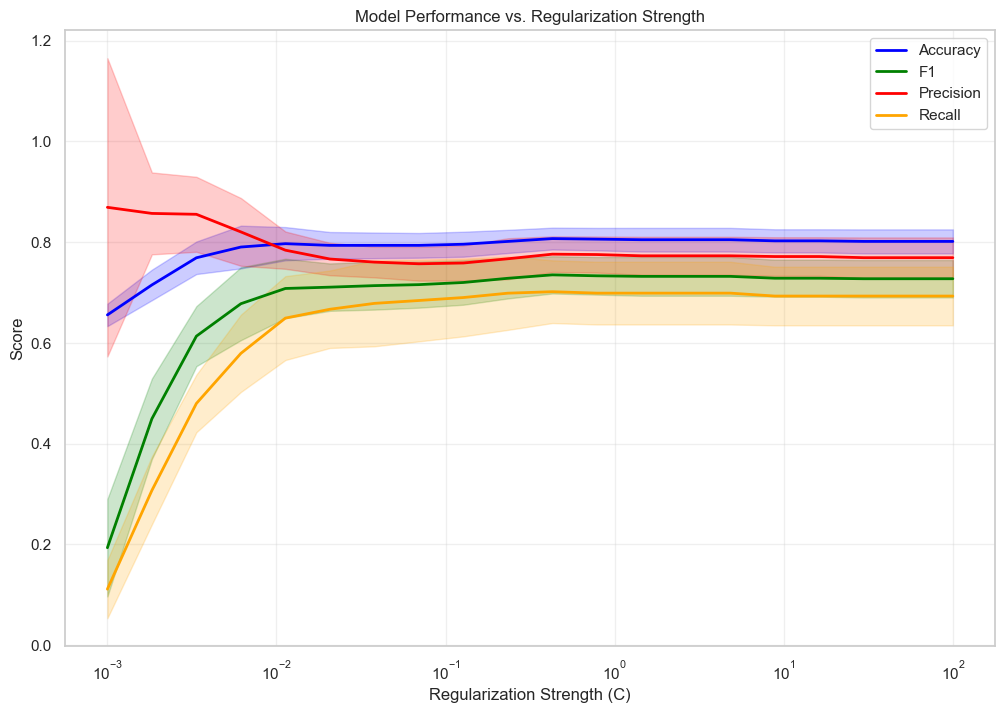

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define parameter grid with correct pipeline syntax
param_grid = {"classifier__C": np.logspace(-3, 2, 20)}
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

# Create pipeline with standardization
pipeline = Pipeline(
    [("scaler", StandardScaler()), ("classifier", LogisticRegression(max_iter=1000))]
)

# Grid search with 10-fold CV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring=scoring,
    refit="accuracy",
    return_train_score=True,
    n_jobs=-1,
)
grid_search.fit(X, y)

print("=" * 50)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 50)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.3f}")
print(f"Best Classifier: {grid_search.best_estimator_}")

# Convert results to DataFrame for easier manipulation
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nAvailable columns in cv_results_:")
print(results_df.columns.tolist())

# Visualize performance across different C values
plt.figure(figsize=(12, 8))

for metric, color in zip(
    ["mean_test_accuracy", "mean_test_f1", "mean_test_precision", "mean_test_recall"],
    ["blue", "green", "red", "orange"],
):
    # Get base metric name (remove 'mean_test_' prefix)
    base_metric = metric.replace("mean_test_", "")

    # Get corresponding standard deviation column name
    std_metric = f"std_test_{base_metric}"

    # Check if columns exist
    if metric in results_df.columns and std_metric in results_df.columns:
        plt.plot(
            results_df["param_classifier__C"],
            results_df[metric],
            label=base_metric.capitalize(),
            color=color,
            linewidth=2,
        )
        plt.fill_between(
            results_df["param_classifier__C"],
            results_df[metric] - results_df[std_metric],
            results_df[metric] + results_df[std_metric],
            alpha=0.2,
            color=color,
        )
    else:
        print(f"Warning: Columns {metric} or {std_metric} not found in results")

plt.xscale("log")
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Score")
plt.title("Model Performance vs. Regularization Strength")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()